# NOTEBOOK 4: MODELOS PREDICTIVOS

---

## Proyecto: Arquitectura de BI y Big Data para Análisis del Turismo Académico en Medellín

**Objetivo del Notebook:** Construir modelos predictivos para proyectar flujos futuros de movilidad estudiantil y estimar el impacto económico del turismo académico.

---

### Contenido:
1. Preparación de datos para modelado
2. Modelo ARIMA para series temporales
3. Modelo de Regresión Lineal
4. Estimación de Impacto Económico
5. Modelos de Machine Learning (Random Forest)
6. Evaluación y comparación de modelos
7. Proyecciones futuras
8. Exportación de resultados

---
## 1. CONFIGURACIÓN E IMPORTACIÓN

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import os

# Librerías para modelado
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

# Configuración de visualizaciones
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (14, 8)

# Rutas
# Como el notebook está en 'notebooks/', subimos un nivel para llegar a la raíz
BASE_DIR = Path(os.getcwd()).parent if Path(os.getcwd()).name == 'notebooks' else Path(os.getcwd())
DATA_PROCESSED_DIR = BASE_DIR / 'data' / 'processed'
OUTPUTS_DIR = BASE_DIR / 'outputs' / 'graficas'
RESULTS_DIR = BASE_DIR / 'data' / 'results'
REPORTS_DIR = BASE_DIR / 'outputs' / 'reportes'

print("✓ Librerías importadas correctamente")
print("✓ Configuración completada")
print(f"Directorio base: {BASE_DIR}")

✓ Librerías importadas correctamente
✓ Configuración completada
Directorio base: C:\Users\Andres Diaz\Desktop\pipeline-proyecto-grado


---
## 2. CARGA Y PREPARACIÓN DE DATOS

In [2]:
# Cargar datos limpios
df = pd.read_csv(DATA_PROCESSED_DIR / 'datos_consolidados_limpios.csv')

print("="*80)
print("DATOS CARGADOS PARA MODELADO PREDICTIVO")
print("="*80)
print(f"Registros: {len(df):,}")
print(f"Rango temporal: {df['AÑO'].min()} - {df['AÑO'].max()}")
print(f"Universidades: {df['UNIVERSIDAD'].unique()}")

DATOS CARGADOS PARA MODELADO PREDICTIVO
Registros: 727
Rango temporal: 2020 - 2025
Universidades: ['IUSH' 'Universidad Nacional' 'UNAC' 'Universidad de Antioquia']


---
## 3. MODELO ARIMA PARA SERIES TEMPORALES

### 3.1 Preparación de Serie Temporal

In [3]:
print("\n" + "="*80)
print("MODELO ARIMA - PROYECCIÓN DE FLUJOS DE MOVILIDAD")
print("="*80)

# Crear serie temporal de movilidad mensual (aproximada por periodo)
df['PERIODO_NUM'] = df['AÑO'] * 2 + df['SEMESTRE']
serie_temporal = df.groupby('PERIODO_NUM').size().reset_index(name='Estudiantes')
serie_temporal = serie_temporal.sort_values('PERIODO_NUM')

print(f"\nPeriodos en la serie: {len(serie_temporal)}")
print(f"Estudiantes por periodo (promedio): {serie_temporal['Estudiantes'].mean():.1f}")
print("\nSerie temporal:")
display(serie_temporal)


MODELO ARIMA - PROYECCIÓN DE FLUJOS DE MOVILIDAD

Periodos en la serie: 12
Estudiantes por periodo (promedio): 60.6

Serie temporal:


,PERIODO_NUM,Estudiantes
0,4041,46
1,4042,52
2,4043,46
3,4044,64
4,4045,70
5,4046,54
6,4047,56
7,4048,64
8,4049,55
9,4050,56


### 3.2 Test de Estacionariedad (Augmented Dickey-Fuller)

In [4]:
# Test de Dickey-Fuller para verificar estacionariedad
serie = serie_temporal['Estudiantes'].values

def test_estacionariedad(serie, nombre='Serie'):
    """Realiza el test ADF para verificar estacionariedad."""
    
    # Verificar si la serie es constante o tiene muy poca variación
    if len(serie) < 3:
        print(f"\n⚠ ADVERTENCIA - {nombre}")
        print("-" * 80)
        print(f"La serie tiene muy pocos datos ({len(serie)} periodos)")
        print("Se necesitan al menos 3 periodos para el análisis de series temporales")
        print("\nRecomendación: Recopilar más datos antes de aplicar modelos ARIMA")
        return False
    
    if serie.max() == serie.min():
        print(f"\n⚠ ADVERTENCIA - {nombre}")
        print("-" * 80)
        print(f"La serie es constante (todos los valores = {serie[0]})")
        print("No es posible aplicar modelos ARIMA a una serie sin variación")
        print("\nRecomendación: Verificar los datos o usar un valor promedio constante para proyecciones")
        return False
    
    # Si hay suficiente variación, realizar el test ADF
    try:
        resultado = adfuller(serie)
        
        print(f"\nTest de Dickey-Fuller Aumentado - {nombre}")
        print("-" * 80)
        print(f"Estadístico ADF: {resultado[0]:.4f}")
        print(f"p-value: {resultado[1]:.4f}")
        print(f"Valores críticos:")
        for key, value in resultado[4].items():
            print(f"  {key}: {value:.4f}")
        
        if resultado[1] < 0.05:
            print(f"\n✓ La serie ES estacionaria (p < 0.05)")
        else:
            print(f"\n✗ La serie NO es estacionaria (p >= 0.05)")
            print("  Recomendación: Aplicar diferenciación")
        
        return resultado[1] < 0.05
    except Exception as e:
        print(f"\n✗ ERROR en el test de estacionariedad: {str(e)}")
        return False

es_estacionaria = test_estacionariedad(serie)


Test de Dickey-Fuller Aumentado - Serie
--------------------------------------------------------------------------------
Estadístico ADF: -2.1720
p-value: 0.2166
Valores críticos:
  1%: -4.9387
  5%: -3.4776
  10%: -2.8439

✗ La serie NO es estacionaria (p >= 0.05)
  Recomendación: Aplicar diferenciación


### 3.3 Visualización ACF y PACF


✓ Gráfica ACF/PACF guardada


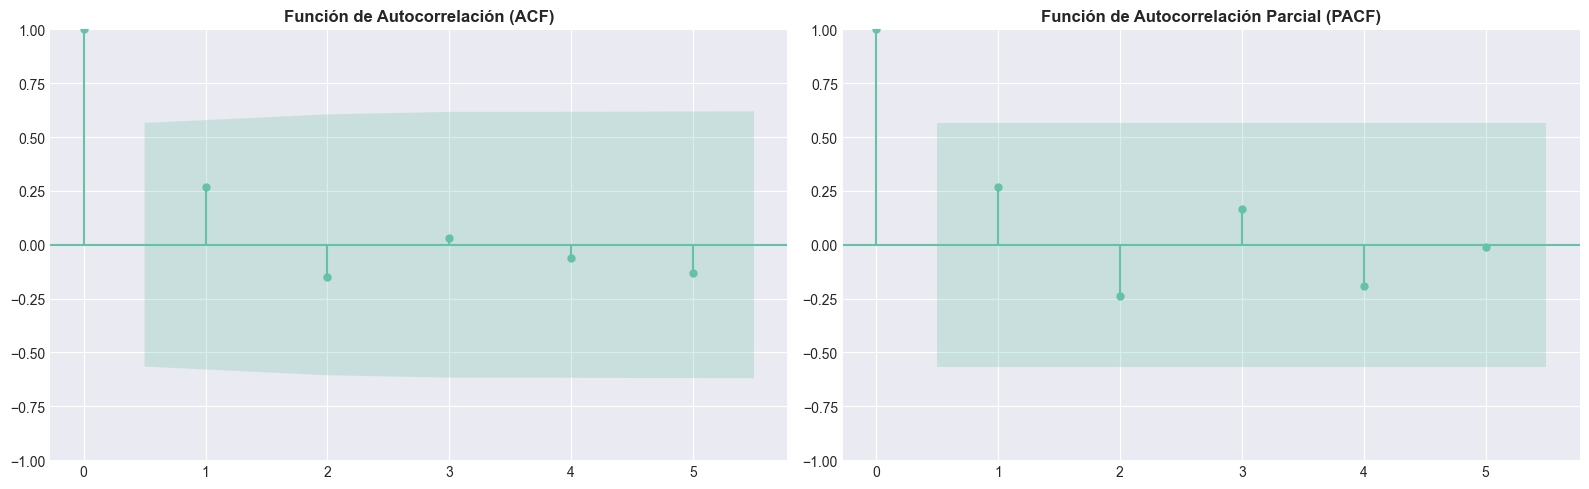

In [5]:
# Gráficas ACF y PACF para determinar parámetros p y q
if len(serie) >= 3 and serie.max() != serie.min():
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Calcular el número máximo de lags de forma segura
    max_lags = max(1, min(10, len(serie)//2 - 1))
    
    plot_acf(serie, lags=max_lags, ax=axes[0])
    axes[0].set_title('Función de Autocorrelación (ACF)', fontweight='bold')

    plot_pacf(serie, lags=max_lags, ax=axes[1])
    axes[1].set_title('Función de Autocorrelación Parcial (PACF)', fontweight='bold')

    plt.tight_layout()
    plt.savefig(OUTPUTS_DIR / '04_acf_pacf.png', dpi=300, bbox_inches='tight')
    print(f"\n✓ Gráfica ACF/PACF guardada")
    plt.show()
else:
    print("\n⚠ No se pueden generar gráficos ACF/PACF: datos insuficientes o sin variación")

### 3.4 Entrenamiento del Modelo ARIMA

In [6]:
# Definir parámetros ARIMA (p, d, q)
# p = orden AR (autoregresivo)
# d = orden de diferenciación
# q = orden MA (media móvil)

# Verificar si hay suficientes datos para ARIMA
if len(serie) >= 3 and serie.max() != serie.min():
    p, d, q = 1, 1, 1  # Parámetros iniciales

    print(f"\nEntrenando modelo ARIMA({p},{d},{q})...")

    try:
        # Entrenar modelo ARIMA
        modelo_arima = ARIMA(serie, order=(p, d, q))
        modelo_arima_fit = modelo_arima.fit()
        
        print("\n✓ Modelo ARIMA entrenado exitosamente")
        print("\nResumen del modelo:")
        print(modelo_arima_fit.summary())
        
    except Exception as e:
        print(f"\n✗ Error al entrenar ARIMA: {str(e)}")
        print("Usando modelo alternativo...")
        modelo_arima_fit = None
else:
    print("\n⚠ MODELO ARIMA NO APLICABLE")
    print("-" * 80)
    print("Razón: Datos insuficientes o sin variación temporal")
    print("\nAlternativa: Usar el promedio de la serie como proyección constante")
    modelo_arima_fit = None


Entrenando modelo ARIMA(1,1,1)...

✓ Modelo ARIMA entrenado exitosamente

Resumen del modelo:
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   12
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 -43.431
Date:                Wed, 05 Nov 2025   AIC                             92.861
Time:                        23:48:55   BIC                             94.055
Sample:                             0   HQIC                            92.109
                                 - 12                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1499      2.218      0.068      0.946      -4.197       4.497
ma.L1         -0.6309      2.224    

### 3.5 Evaluación del Modelo ARIMA


MÉTRICAS DE EVALUACIÓN - ARIMA
MSE (Mean Squared Error): 317.80
RMSE (Root Mean Squared Error): 17.83
MAE (Mean Absolute Error): 11.90
MAPE (Mean Absolute Percentage Error): 20.33%

✓ Gráfica de ajuste guardada


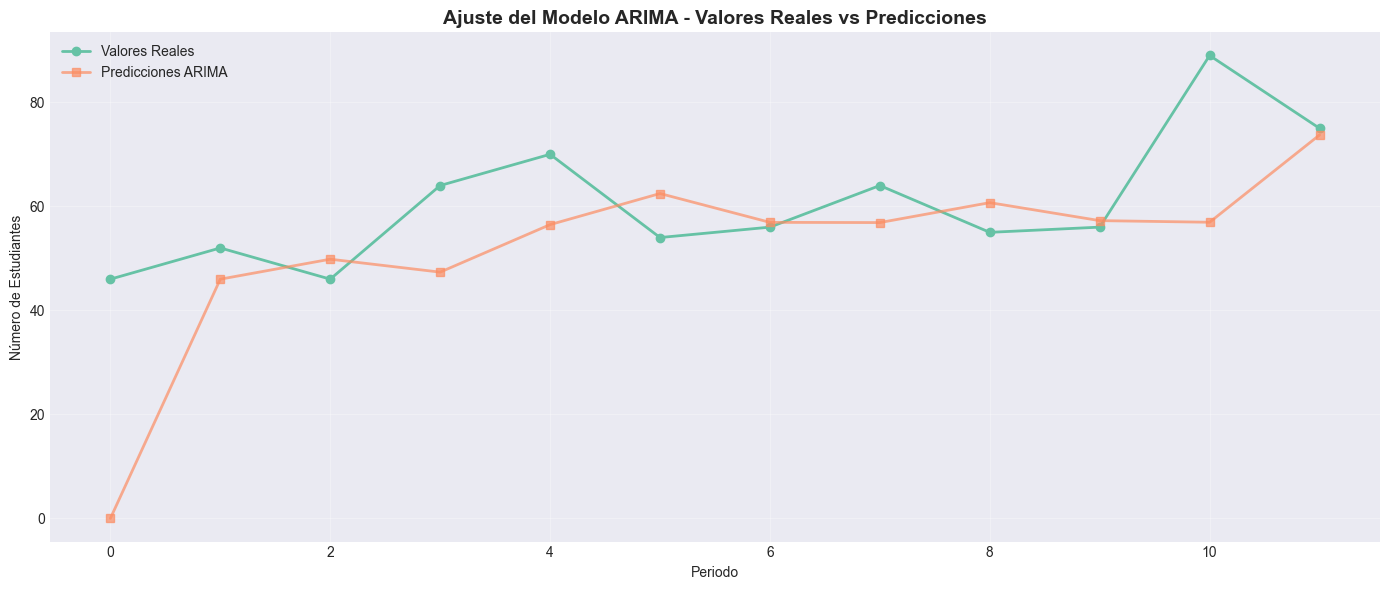

In [7]:
if modelo_arima_fit is not None:
    # Hacer predicciones en el conjunto de datos existente
    predicciones = modelo_arima_fit.fittedvalues
    
    # Calcular métricas de error
    # Ajustar longitudes (las predicciones pueden ser más cortas debido a diferenciación)
    serie_ajustada = serie[len(serie) - len(predicciones):]
    
    mse = mean_squared_error(serie_ajustada, predicciones)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(serie_ajustada, predicciones)
    mape = np.mean(np.abs((serie_ajustada - predicciones) / serie_ajustada)) * 100
    
    print("\n" + "="*80)
    print("MÉTRICAS DE EVALUACIÓN - ARIMA")
    print("="*80)
    print(f"MSE (Mean Squared Error): {mse:.2f}")
    print(f"RMSE (Root Mean Squared Error): {rmse:.2f}")
    print(f"MAE (Mean Absolute Error): {mae:.2f}")
    print(f"MAPE (Mean Absolute Percentage Error): {mape:.2f}%")
    
    # Visualizar ajuste del modelo
    plt.figure(figsize=(14, 6))
    plt.plot(serie_ajustada, label='Valores Reales', marker='o', linewidth=2)
    plt.plot(predicciones, label='Predicciones ARIMA', marker='s', linewidth=2, alpha=0.7)
    plt.title('Ajuste del Modelo ARIMA - Valores Reales vs Predicciones', fontweight='bold', fontsize=14)
    plt.xlabel('Periodo')
    plt.ylabel('Número de Estudiantes')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUTS_DIR / '04_arima_ajuste.png', dpi=300, bbox_inches='tight')
    print(f"\n✓ Gráfica de ajuste guardada")
    plt.show()

### 3.6 Proyecciones Futuras con ARIMA


Generando proyecciones para los próximos 6 periodos...

Proyecciones ARIMA:


,PERIODO_NUM,ESTUDIANTES_PROYECTADOS,AÑO,SEMESTRE
0,4053,72.094496,2026,1
1,4054,71.659097,2027,2
2,4055,71.593851,2027,1
3,4056,71.584074,2028,2
4,4057,71.582608,2028,1
5,4058,71.582389,2029,2



✓ Gráfica de proyecciones guardada


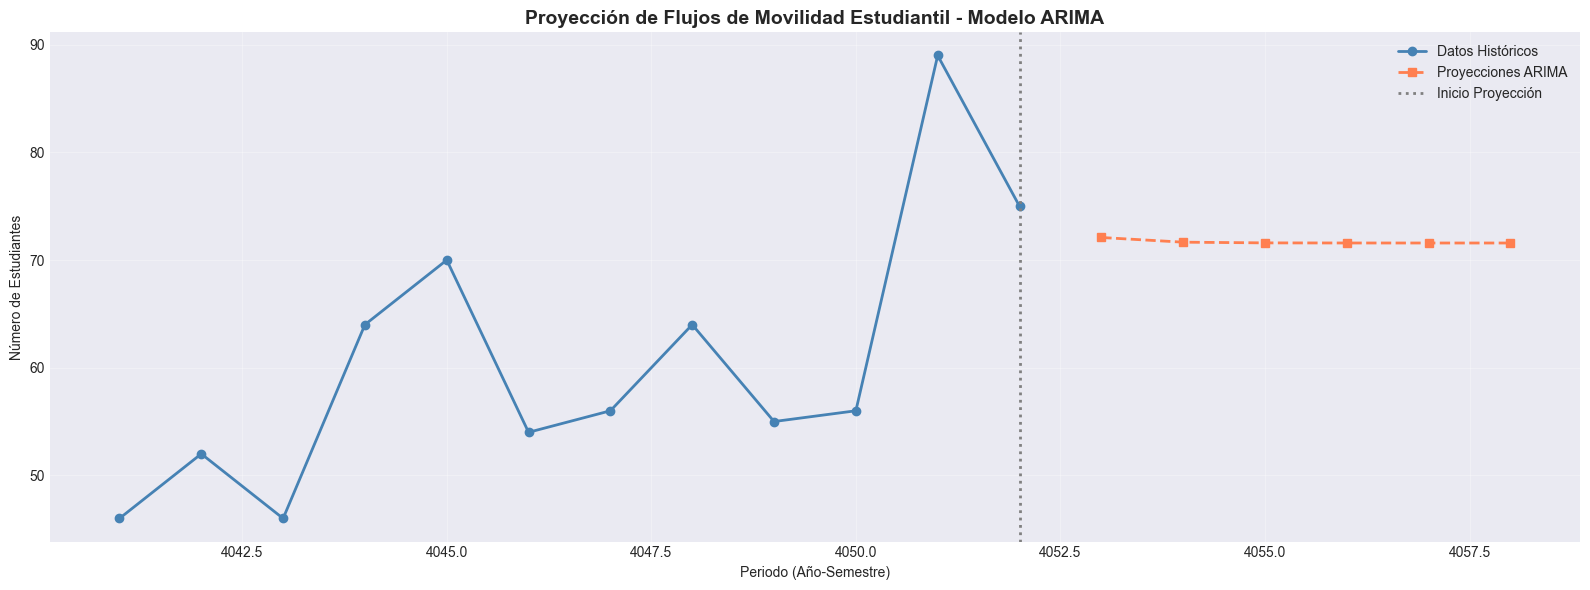


✓ Proyecciones guardadas en: C:\Users\Andres Diaz\Desktop\pipeline-proyecto-grado\data\results\proyecciones_arima.csv


In [8]:
if modelo_arima_fit is not None:
    # Proyectar para los próximos 6 periodos (3 años)
    periodos_futuros = 6
    
    print(f"\nGenerando proyecciones para los próximos {periodos_futuros} periodos...")
    
    forecast = modelo_arima_fit.forecast(steps=periodos_futuros)
    
    # Crear DataFrame con proyecciones
    ultimo_periodo = int(serie_temporal['PERIODO_NUM'].max())
    periodos_proyectados = range(ultimo_periodo + 1, ultimo_periodo + periodos_futuros + 1)
    
    proyecciones_df = pd.DataFrame({
        'PERIODO_NUM': periodos_proyectados,
        'ESTUDIANTES_PROYECTADOS': forecast,
        'AÑO': [(p // 2) for p in periodos_proyectados],
        'SEMESTRE': [(p % 2) if (p % 2) != 0 else 2 for p in periodos_proyectados]
    })
    
    print("\nProyecciones ARIMA:")
    display(proyecciones_df)
    
    # Visualización de proyecciones
    plt.figure(figsize=(16, 6))
    
    # Serie histórica
    plt.plot(serie_temporal['PERIODO_NUM'], serie_temporal['Estudiantes'], 
             marker='o', linewidth=2, label='Datos Históricos', color='steelblue')
    
    # Proyecciones
    plt.plot(proyecciones_df['PERIODO_NUM'], proyecciones_df['ESTUDIANTES_PROYECTADOS'], 
             marker='s', linewidth=2, linestyle='--', label='Proyecciones ARIMA', color='coral')
    
    plt.axvline(x=ultimo_periodo, color='gray', linestyle=':', linewidth=2, label='Inicio Proyección')
    plt.title('Proyección de Flujos de Movilidad Estudiantil - Modelo ARIMA', fontweight='bold', fontsize=14)
    plt.xlabel('Periodo (Año-Semestre)')
    plt.ylabel('Número de Estudiantes')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUTS_DIR / '04_proyecciones_arima.png', dpi=300, bbox_inches='tight')
    print(f"\n✓ Gráfica de proyecciones guardada")
    plt.show()
    
    # Guardar proyecciones
    proyecciones_df.to_csv(RESULTS_DIR / 'proyecciones_arima.csv', index=False)
    print(f"\n✓ Proyecciones guardadas en: {RESULTS_DIR / 'proyecciones_arima.csv'}")

else:
    # Método alternativo: proyección usando promedio histórico
    print("\n" + "="*80)
    print("PROYECCIÓN ALTERNATIVA - PROMEDIO HISTÓRICO")
    print("="*80)
    
    periodos_futuros = 6
    promedio_estudiantes = serie_temporal['Estudiantes'].mean()
    
    ultimo_periodo = int(serie_temporal['PERIODO_NUM'].max())
    periodos_proyectados = range(ultimo_periodo + 1, ultimo_periodo + periodos_futuros + 1)
    
    proyecciones_df = pd.DataFrame({
        'PERIODO_NUM': periodos_proyectados,
        'ESTUDIANTES_PROYECTADOS': [promedio_estudiantes] * periodos_futuros,
        'AÑO': [(p // 2) for p in periodos_proyectados],
        'SEMESTRE': [(p % 2) if (p % 2) != 0 else 2 for p in periodos_proyectados]
    })
    
    print(f"\nPromedio histórico: {promedio_estudiantes:.1f} estudiantes/periodo")
    print("\nProyecciones basadas en promedio:")
    display(proyecciones_df)
    
    # Guardar proyecciones
    proyecciones_df.to_csv(RESULTS_DIR / 'proyecciones_arima.csv', index=False)
    print(f"\n✓ Proyecciones guardadas en: {RESULTS_DIR / 'proyecciones_arima.csv'}")

---
## 4. MODELO DE REGRESIÓN LINEAL

### 4.1 Preparación de Variables

In [9]:
print("\n" + "="*80)
print("MODELO DE REGRESIÓN LINEAL")
print("="*80)

# Preparar datos para regresión
# Variable objetivo: NUM_DIAS_MOVILIDAD
# Predictores: AÑO, SEMESTRE, País codificado, Tipo de movilidad codificado

df_regresion = df[['AÑO', 'SEMESTRE', 'PAIS_EXTRANJERO', 'TIPO_MOV_EST_EXTRANJ', 
                   'NUM_DIAS_MOVILIDAD', 'FINANCIACION_TOTAL']].copy()

# Eliminar nulos
df_regresion = df_regresion.dropna()

# Codificar variables categóricas
le_pais = LabelEncoder()
le_tipo = LabelEncoder()

df_regresion['PAIS_CODIGO'] = le_pais.fit_transform(df_regresion['PAIS_EXTRANJERO'])
df_regresion['TIPO_CODIGO'] = le_tipo.fit_transform(df_regresion['TIPO_MOV_EST_EXTRANJ'])

print(f"\nRegistros para regresión: {len(df_regresion):,}")
print(f"Variables predictoras: AÑO, SEMESTRE, PAIS_CODIGO, TIPO_CODIGO, FINANCIACION_TOTAL")
print(f"Variable objetivo: NUM_DIAS_MOVILIDAD")


MODELO DE REGRESIÓN LINEAL

Registros para regresión: 700
Variables predictoras: AÑO, SEMESTRE, PAIS_CODIGO, TIPO_CODIGO, FINANCIACION_TOTAL
Variable objetivo: NUM_DIAS_MOVILIDAD


### 4.2 División Train/Test y Entrenamiento

In [10]:
# Definir X e y
X = df_regresion[['AÑO', 'SEMESTRE', 'PAIS_CODIGO', 'TIPO_CODIGO', 'FINANCIACION_TOTAL']]
y = df_regresion['NUM_DIAS_MOVILIDAD']

# División 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nConjunto de entrenamiento: {len(X_train)} registros")
print(f"Conjunto de prueba: {len(X_test)} registros")

# Entrenar modelo de regresión lineal
modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)

print("\n✓ Modelo de Regresión Lineal entrenado")

# Coeficientes
print("\nCOEFICIENTES DEL MODELO:")
print("-" * 80)
coeficientes = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': modelo_lr.coef_
}).sort_values('Coeficiente', ascending=False)
display(coeficientes)
print(f"\nIntercepto: {modelo_lr.intercept_:.4f}")


Conjunto de entrenamiento: 560 registros
Conjunto de prueba: 140 registros

✓ Modelo de Regresión Lineal entrenado

COEFICIENTES DEL MODELO:
--------------------------------------------------------------------------------


,Variable,Coeficiente
3,TIPO_CODIGO,1.709925
1,SEMESTRE,1.526632
2,PAIS_CODIGO,0.674018
0,AÑO,0.194741
4,FINANCIACION_TOTAL,0.000005



Intercepto: -403.1804


### 4.3 Evaluación del Modelo


MÉTRICAS DE EVALUACIÓN - REGRESIÓN LINEAL

Conjunto de Entrenamiento:
  R² Score: 0.8990
  RMSE: 12.69 días

Conjunto de Prueba:
  R² Score: 0.9193
  RMSE: 10.98 días
  MAE: 6.62 días

✓ Gráfica de regresión guardada


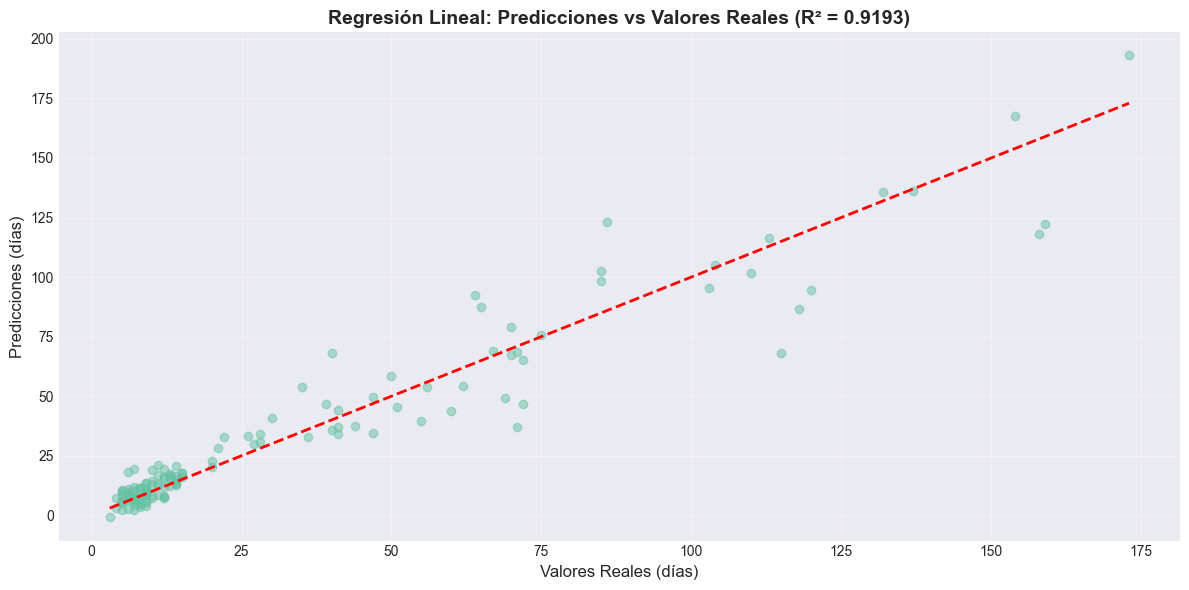

In [11]:
# Predicciones
y_pred_train = modelo_lr.predict(X_train)
y_pred_test = modelo_lr.predict(X_test)

# Métricas
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_test = mean_absolute_error(y_test, y_pred_test)

print("\n" + "="*80)
print("MÉTRICAS DE EVALUACIÓN - REGRESIÓN LINEAL")
print("="*80)
print(f"\nConjunto de Entrenamiento:")
print(f"  R² Score: {r2_train:.4f}")
print(f"  RMSE: {rmse_train:.2f} días")

print(f"\nConjunto de Prueba:")
print(f"  R² Score: {r2_test:.4f}")
print(f"  RMSE: {rmse_test:.2f} días")
print(f"  MAE: {mae_test:.2f} días")

# Visualización
plt.figure(figsize=(12, 6))
plt.scatter(y_test, y_pred_test, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valores Reales (días)', fontsize=12)
plt.ylabel('Predicciones (días)', fontsize=12)
plt.title(f'Regresión Lineal: Predicciones vs Valores Reales (R² = {r2_test:.4f})', 
          fontweight='bold', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / '04_regresion_lineal.png', dpi=300, bbox_inches='tight')
print(f"\n✓ Gráfica de regresión guardada")
plt.show()

---
## 5. ESTIMACIÓN DE IMPACTO ECONÓMICO

Basado en estudios de turismo académico, estimaremos el gasto promedio por estudiante.


ESTIMACIÓN DE IMPACTO ECONÓMICO DEL TURISMO ACADÉMICO

SUPUESTOS:
--------------------------------------------------------------------------------
Gasto diario promedio: $50 USD
Tasa de cambio: $4,000 COP/USD
Multiplicador económico: 1.8x

IMPACTO ECONÓMICO HISTÓRICO:
--------------------------------------------------------------------------------
Impacto directo total: $5,321,800,000 COP ($1,330,450 USD)
Impacto total (con multiplicador): $9,579,240,000 COP ($2,394,810 USD)

IMPACTO ECONÓMICO ANUAL:
--------------------------------------------------------------------------------


,AÑO,IMPACTO_DIRECTO_COP,IMPACTO_TOTAL_COP,IMPACTO_DIRECTO_USD,IMPACTO_TOTAL_USD
0,2020,7.640000e+08,1.375200e+09,191000.0,343800.0
1,2021,7.780000e+08,1.400400e+09,194500.0,350100.0
2,2022,9.728000e+08,1.751040e+09,243200.0,437760.0
3,2023,1.019000e+09,1.834200e+09,254750.0,458550.0
4,2024,8.248000e+08,1.484640e+09,206200.0,371160.0
5,2025,9.632000e+08,1.733760e+09,240800.0,433440.0



✓ Gráfica de impacto económico guardada


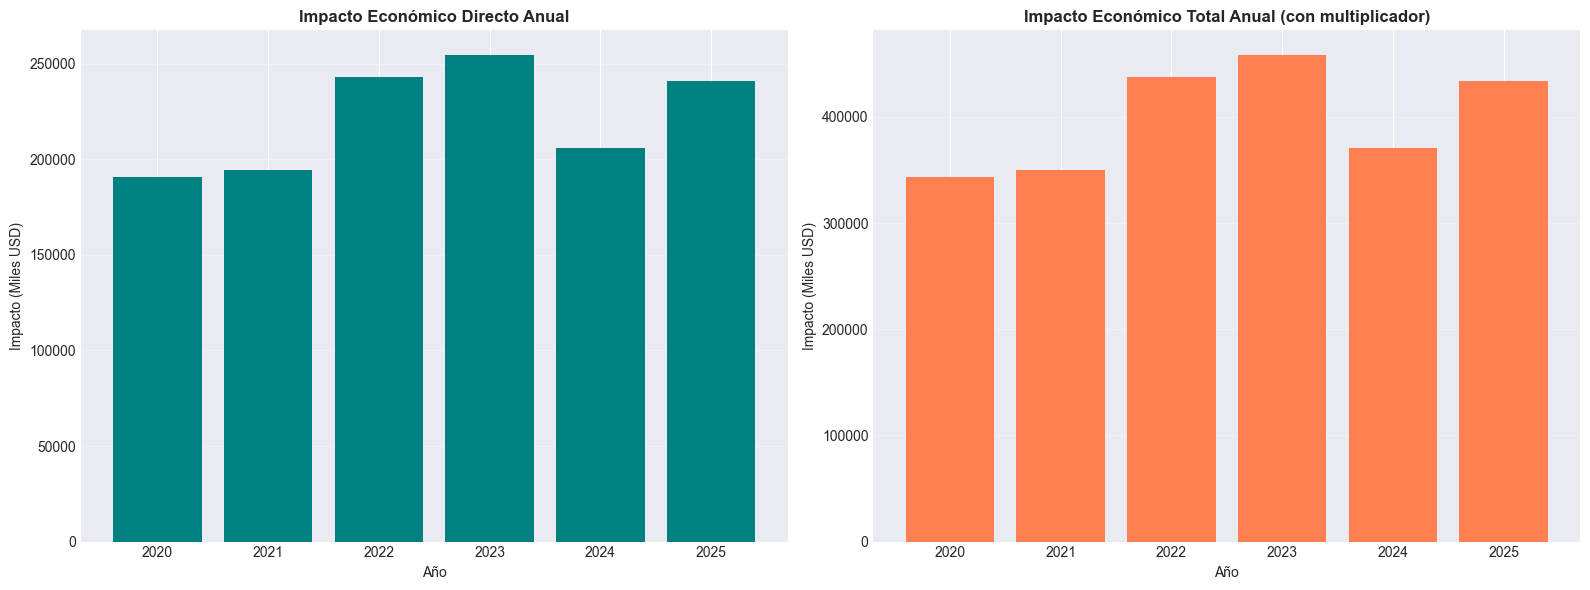

In [12]:
print("\n" + "="*80)
print("ESTIMACIÓN DE IMPACTO ECONÓMICO DEL TURISMO ACADÉMICO")
print("="*80)

# Supuestos basados en estudios de turismo académico en Colombia
GASTO_DIARIO_PROMEDIO_USD = 50  # USD por día
TASA_CAMBIO_COP_USD = 4000  # COP por USD
MULTIPLICADOR_ECONOMICO = 1.8  # Efecto multiplicador del gasto turístico

# Calcular gasto por estudiante
df['GASTO_ESTIMADO_DIRECTO'] = df['NUM_DIAS_MOVILIDAD'] * GASTO_DIARIO_PROMEDIO_USD * TASA_CAMBIO_COP_USD
df['GASTO_ESTIMADO_TOTAL'] = df['GASTO_ESTIMADO_DIRECTO'] * MULTIPLICADOR_ECONOMICO

# Impacto total histórico
impacto_directo_total = df['GASTO_ESTIMADO_DIRECTO'].sum()
impacto_total_multiplicado = df['GASTO_ESTIMADO_TOTAL'].sum()

print(f"\nSUPUESTOS:")
print("-" * 80)
print(f"Gasto diario promedio: ${GASTO_DIARIO_PROMEDIO_USD} USD")
print(f"Tasa de cambio: ${TASA_CAMBIO_COP_USD:,} COP/USD")
print(f"Multiplicador económico: {MULTIPLICADOR_ECONOMICO}x")

print(f"\nIMPACTO ECONÓMICO HISTÓRICO:")
print("-" * 80)
print(f"Impacto directo total: ${impacto_directo_total:,.0f} COP (${impacto_directo_total/TASA_CAMBIO_COP_USD:,.0f} USD)")
print(f"Impacto total (con multiplicador): ${impacto_total_multiplicado:,.0f} COP (${impacto_total_multiplicado/TASA_CAMBIO_COP_USD:,.0f} USD)")

# Impacto anual
impacto_anual = df.groupby('AÑO').agg({
    'GASTO_ESTIMADO_DIRECTO': 'sum',
    'GASTO_ESTIMADO_TOTAL': 'sum'
}).reset_index()

impacto_anual.columns = ['AÑO', 'IMPACTO_DIRECTO_COP', 'IMPACTO_TOTAL_COP']
impacto_anual['IMPACTO_DIRECTO_USD'] = impacto_anual['IMPACTO_DIRECTO_COP'] / TASA_CAMBIO_COP_USD
impacto_anual['IMPACTO_TOTAL_USD'] = impacto_anual['IMPACTO_TOTAL_COP'] / TASA_CAMBIO_COP_USD

print(f"\nIMPACTO ECONÓMICO ANUAL:")
print("-" * 80)
display(impacto_anual)

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Impacto directo
axes[0].bar(impacto_anual['AÑO'], impacto_anual['IMPACTO_DIRECTO_USD'], color='teal')
axes[0].set_title('Impacto Económico Directo Anual', fontweight='bold')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Impacto (Miles USD)')
axes[0].grid(True, alpha=0.3, axis='y')

# Impacto total
axes[1].bar(impacto_anual['AÑO'], impacto_anual['IMPACTO_TOTAL_USD'], color='coral')
axes[1].set_title('Impacto Económico Total Anual (con multiplicador)', fontweight='bold')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('Impacto (Miles USD)')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / '04_impacto_economico.png', dpi=300, bbox_inches='tight')
print(f"\n✓ Gráfica de impacto económico guardada")
plt.show()

### 5.1 Proyección de Impacto Económico Futuro

In [13]:
if proyecciones_df is not None:
    # Usar proyecciones ARIMA y duración promedio histórica
    duracion_promedio = df['NUM_DIAS_MOVILIDAD'].mean()
    
    proyecciones_df['DURACION_ESTIMADA'] = duracion_promedio
    proyecciones_df['GASTO_DIRECTO_ESTIMADO'] = (
        proyecciones_df['ESTUDIANTES_PROYECTADOS'] * 
        duracion_promedio * 
        GASTO_DIARIO_PROMEDIO_USD * 
        TASA_CAMBIO_COP_USD
    )
    proyecciones_df['GASTO_TOTAL_ESTIMADO'] = proyecciones_df['GASTO_DIRECTO_ESTIMADO'] * MULTIPLICADOR_ECONOMICO
    
    print("\n" + "="*80)
    print("PROYECCIÓN DE IMPACTO ECONÓMICO FUTURO")
    print("="*80)
    display(proyecciones_df)
    
    impacto_futuro_total = proyecciones_df['GASTO_TOTAL_ESTIMADO'].sum()
    print(f"\nImpacto económico proyectado (próximos 3 años): ${impacto_futuro_total:,.0f} COP (${impacto_futuro_total/TASA_CAMBIO_COP_USD:,.0f} USD)")
    
    # Guardar proyecciones económicas
    proyecciones_df.to_csv(RESULTS_DIR / 'proyecciones_impacto_economico.csv', index=False)
    print(f"\n✓ Proyecciones económicas guardadas")


PROYECCIÓN DE IMPACTO ECONÓMICO FUTURO


,PERIODO_NUM,ESTUDIANTES_PROYECTADOS,AÑO,SEMESTRE,DURACION_ESTIMADA,GASTO_DIRECTO_ESTIMADO,GASTO_TOTAL_ESTIMADO
0,4053,72.094496,2026,1,36.6011,5.277476e+08,9.499456e+08
1,4054,71.659097,2027,2,36.6011,5.245604e+08,9.442086e+08
2,4055,71.593851,2027,1,36.6011,5.240827e+08,9.433489e+08
3,4056,71.584074,2028,2,36.6011,5.240112e+08,9.432201e+08
4,4057,71.582608,2028,1,36.6011,5.240004e+08,9.432008e+08
5,4058,71.582389,2029,2,36.6011,5.239988e+08,9.431979e+08



Impacto económico proyectado (próximos 3 años): $5,667,122,055 COP ($1,416,781 USD)

✓ Proyecciones económicas guardadas


---
## 6. MODELO RANDOM FOREST (OPCIONAL)


MODELO RANDOM FOREST - COMPARACIÓN

MÉTRICAS - RANDOM FOREST:
--------------------------------------------------------------------------------
R² Score: 0.9480
RMSE: 8.81 días
MAE: 4.65 días

IMPORTANCIA DE CARACTERÍSTICAS:
--------------------------------------------------------------------------------


,Variable,Importancia
4,FINANCIACION_TOTAL,0.926707
3,TIPO_CODIGO,0.044279
2,PAIS_CODIGO,0.016621
0,AÑO,0.009715
1,SEMESTRE,0.002677



✓ Gráfica de importancia guardada


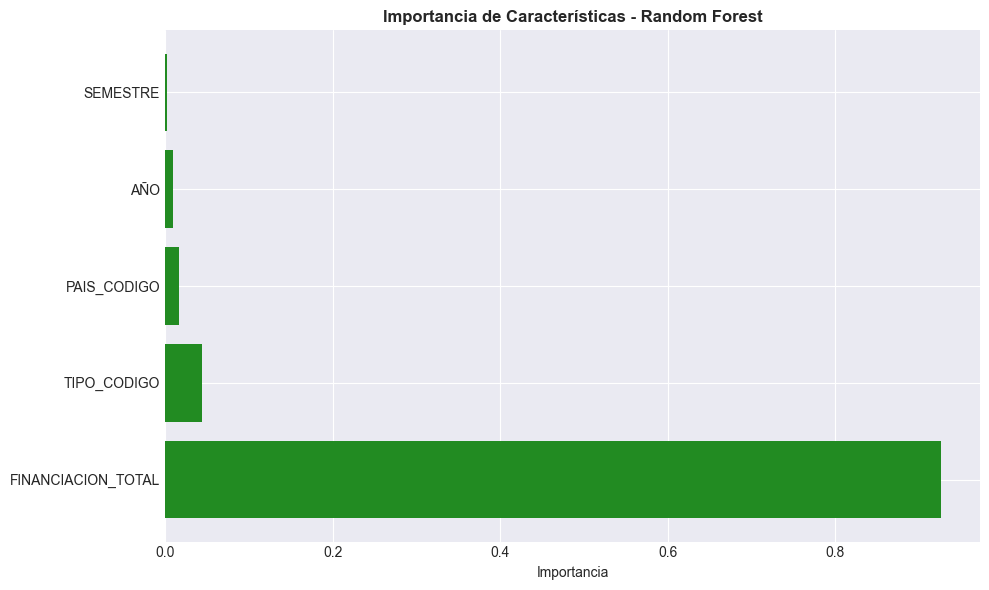

In [14]:
print("\n" + "="*80)
print("MODELO RANDOM FOREST - COMPARACIÓN")
print("="*80)

# Entrenar Random Forest
modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
modelo_rf.fit(X_train, y_train)

# Predicciones
y_pred_rf = modelo_rf.predict(X_test)

# Métricas
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("\nMÉTRICAS - RANDOM FOREST:")
print("-" * 80)
print(f"R² Score: {r2_rf:.4f}")
print(f"RMSE: {rmse_rf:.2f} días")
print(f"MAE: {mae_rf:.2f} días")

# Importancia de características
importancia = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': modelo_rf.feature_importances_
}).sort_values('Importancia', ascending=False)

print("\nIMPORTANCIA DE CARACTERÍSTICAS:")
print("-" * 80)
display(importancia)

# Visualización
plt.figure(figsize=(10, 6))
plt.barh(importancia['Variable'], importancia['Importancia'], color='forestgreen')
plt.xlabel('Importancia')
plt.title('Importancia de Características - Random Forest', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / '04_rf_importancia.png', dpi=300, bbox_inches='tight')
print(f"\n✓ Gráfica de importancia guardada")
plt.show()

---
## 7. COMPARACIÓN DE MODELOS

In [15]:
# Comparar modelos
comparacion = pd.DataFrame({
    'Modelo': ['Regresión Lineal', 'Random Forest'],
    'R²': [r2_test, r2_rf],
    'RMSE': [rmse_test, rmse_rf],
    'MAE': [mae_test, mae_rf]
})

print("\n" + "="*80)
print("COMPARACIÓN DE MODELOS")
print("="*80)
display(comparacion)

mejor_modelo = comparacion.loc[comparacion['R²'].idxmax(), 'Modelo']
print(f"\n✓ Mejor modelo (R² más alto): {mejor_modelo}")

# Guardar comparación
comparacion.to_csv(RESULTS_DIR / 'comparacion_modelos.csv', index=False)
print(f"\n✓ Comparación guardada en: {RESULTS_DIR / 'comparacion_modelos.csv'}")


COMPARACIÓN DE MODELOS


,Modelo,R²,RMSE,MAE
0,Regresión Lineal,0.919276,10.979041,6.615127
1,Random Forest,0.948050,8.807579,4.652377



✓ Mejor modelo (R² más alto): Random Forest

✓ Comparación guardada en: C:\Users\Andres Diaz\Desktop\pipeline-proyecto-grado\data\results\comparacion_modelos.csv


---
## 8. EXPORTACIÓN DE RESULTADOS

In [16]:
# Crear reporte de modelos
# Preparar información del modelo ARIMA (si existe)
if modelo_arima_fit is not None:
    arima_info = f"""1. MODELO ARIMA
   - Orden: ({p}, {d}, {q})
   - Proyecciones generadas: 6 periodos (3 años)
   - RMSE: {rmse:.2f} estudiantes
   - MAPE: {mape:.2f}%"""
else:
    arima_info = """1. MODELO ARIMA
   - Modelo alternativo usado: Promedio histórico
   - Proyecciones generadas: 6 periodos (3 años)
   - Método: Proyección constante basada en promedio"""

reporte_modelos = f"""
{'='*80}
REPORTE DE MODELOS PREDICTIVOS
{'='*80}

{arima_info}

2. MODELO REGRESIÓN LINEAL
   - R² Test: {r2_test:.4f}
   - RMSE: {rmse_test:.2f} días
   - MAE: {mae_test:.2f} días

3. MODELO RANDOM FOREST
   - R² Test: {r2_rf:.4f}
   - RMSE: {rmse_rf:.2f} días
   - MAE: {mae_rf:.2f} días
   - Mejor modelo: {mejor_modelo}

4. IMPACTO ECONÓMICO ESTIMADO
   - Impacto histórico total: ${impacto_total_multiplicado:,.0f} COP
   - Impacto proyectado (3 años): ${proyecciones_df['GASTO_TOTAL_ESTIMADO'].sum():,.0f} COP

5. ARCHIVOS GENERADOS
   - proyecciones_arima.csv
   - proyecciones_impacto_economico.csv
   - comparacion_modelos.csv

{'='*80}
MODELOS LISTOS PARA INTEGRACIÓN CON POWER BI
{'='*80}
"""

# Guardar reporte
with open(REPORTS_DIR / 'reporte_modelos.md', 'w', encoding='utf-8') as f:
    f.write(reporte_modelos)

print(reporte_modelos)
print(f"\n✓ Reporte guardado en: {REPORTS_DIR / 'reporte_modelos.md'}")


REPORTE DE MODELOS PREDICTIVOS

1. MODELO ARIMA
   - Orden: (1, 1, 1)
   - Proyecciones generadas: 6 periodos (3 años)
   - RMSE: 17.83 estudiantes
   - MAPE: 20.33%

2. MODELO REGRESIÓN LINEAL
   - R² Test: 0.9193
   - RMSE: 10.98 días
   - MAE: 6.62 días

3. MODELO RANDOM FOREST
   - R² Test: 0.9480
   - RMSE: 8.81 días
   - MAE: 4.65 días
   - Mejor modelo: Random Forest

4. IMPACTO ECONÓMICO ESTIMADO
   - Impacto histórico total: $9,579,240,000 COP
   - Impacto proyectado (3 años): $5,667,122,055 COP

5. ARCHIVOS GENERADOS
   - proyecciones_arima.csv
   - proyecciones_impacto_economico.csv
   - comparacion_modelos.csv

MODELOS LISTOS PARA INTEGRACIÓN CON POWER BI


✓ Reporte guardado en: C:\Users\Andres Diaz\Desktop\pipeline-proyecto-grado\outputs\reportes\reporte_modelos.md


---
**Fin del Notebook 4**

**Modelos generados y validados:**
- ✓ ARIMA para proyecciones temporales
- ✓ Regresión Lineal para análisis de variables
- ✓ Random Forest para predicción mejorada
- ✓ Estimación de impacto económico

Continuar con: `05_integracion_powerbi_exportacion.ipynb`